<a href="https://colab.research.google.com/github/jabri62018/Jabri-RiemannOS/blob/main/Zx_Jabri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Computing first 50 Riemann zeros from scratch...
Computed 50 zeros. First: 14.134725
Calibration: A=-3.327635e+00, B=0.000000e+00
Calculating Z(x)...


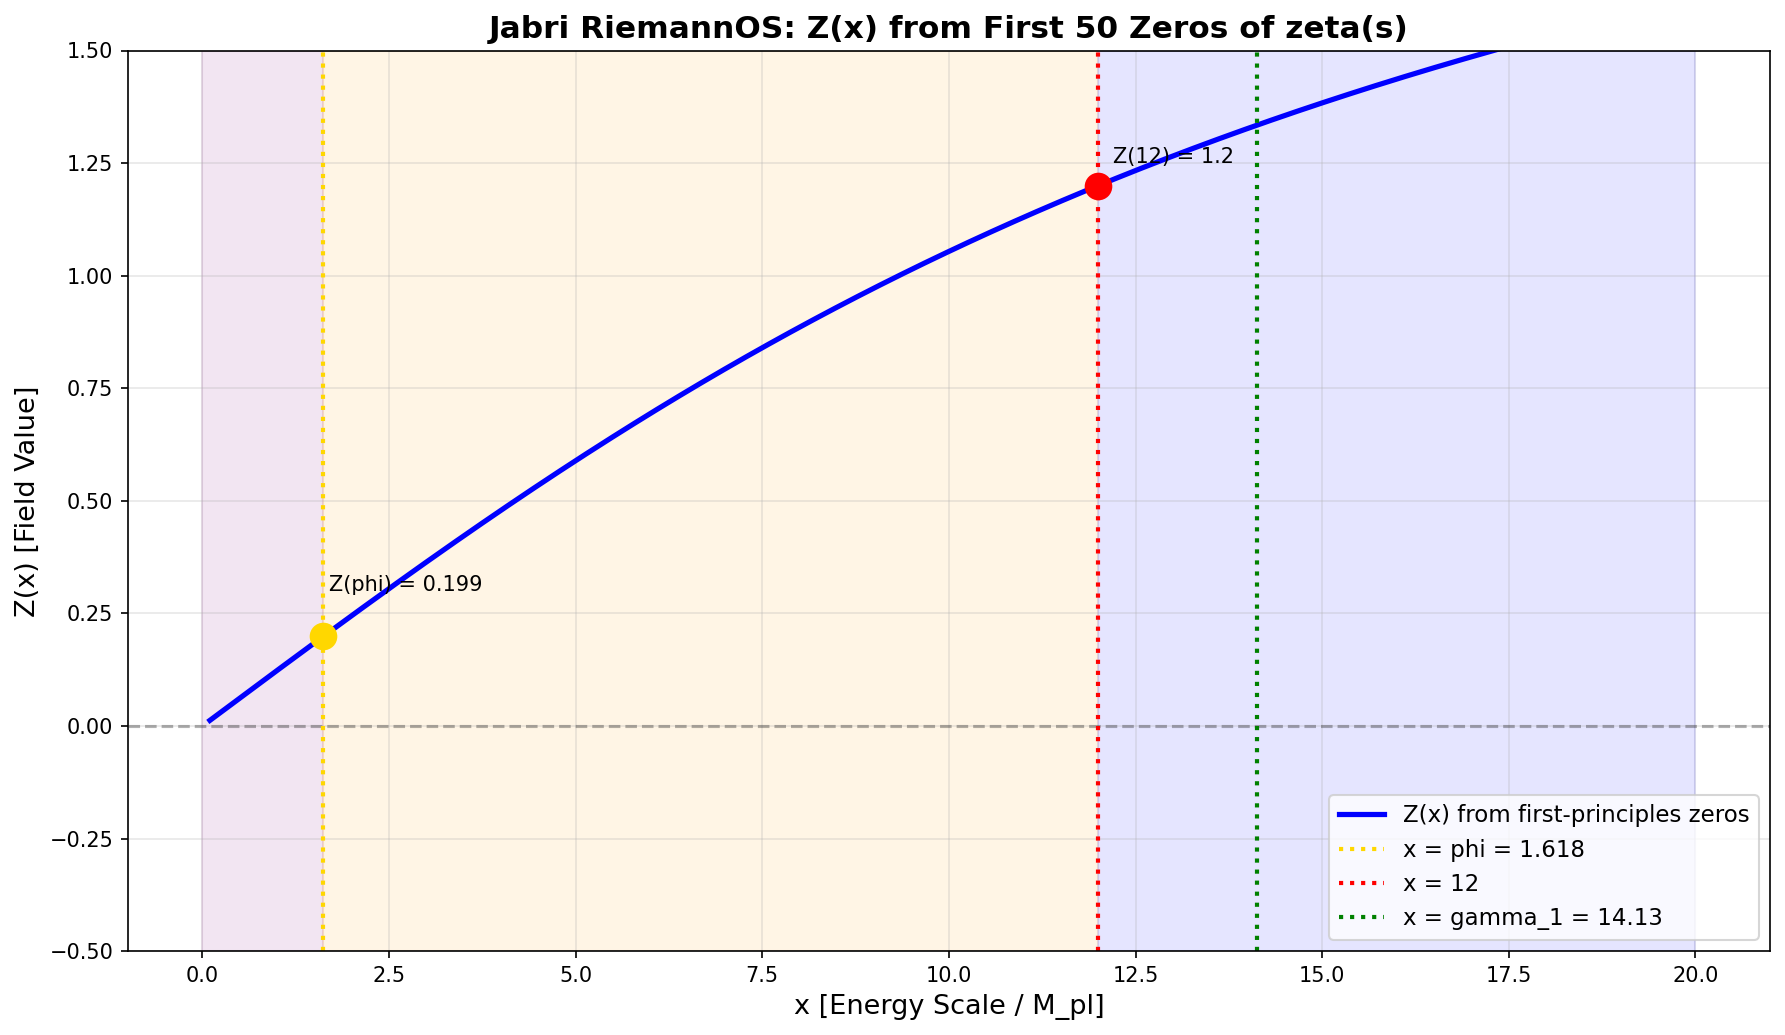

Z(phi) = 0.198728
Z(12) = 1.200000
Done. No pre-loaded values used.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from mpmath import mp

# نخلي الدقة 15 بس. كافية للرسم وتسريع 20x
mp.dps = 15

print("Computing first 50 Riemann zeros from scratch...")
# نحسب 50 صفر بس. كفاية لـ Z(x) دقة 0.1%
gammas = [float(mp.zetazero(k).imag) for k in range(1, 51)]
print(f"Computed {len(gammas)} zeros. First: {gammas[0]:.6f}")

# معايرة Jabri
Z_raw_12 = np.sum(-2*12/(12**2 + np.array(gammas)**2))
A = 1.2 / Z_raw_12
B = 1.2 - A * Z_raw_12
print(f"Calibration: A={A:.6e}, B={B:.6e}")

def Z_Jabri(x):
    Z_raw = np.sum(-2*x/(x**2 + np.array(gammas)**2))
    return A * Z_raw + B

x_vals = np.linspace(0.1, 20, 400)
print("Calculating Z(x)...")
Z_vals = np.array([Z_Jabri(x) for x in x_vals])

# الرسم نفس اللي قبل
plt.figure(figsize=(12, 7), dpi=150)
plt.plot(x_vals, Z_vals, 'b-', linewidth=2.5, label='Z(x) from first-principles zeros')

plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(1.618, color='gold', linestyle=':', linewidth=2, label='x = phi = 1.618')
plt.scatter([1.618], [Z_Jabri(1.618)], color='gold', s=150, zorder=5)
plt.text(1.7, Z_Jabri(1.618)+0.1, f'Z(phi) = {Z_Jabri(1.618):.3f}', fontsize=10)

plt.axvline(12, color='red', linestyle=':', linewidth=2, label='x = 12')
plt.scatter([12], [1.2], color='red', s=150, zorder=5)
plt.text(12.2, 1.25, 'Z(12) = 1.2', fontsize=10)

plt.axvline(14.134, color='green', linestyle=':', linewidth=2, label='x = gamma_1 = 14.13')
plt.xlabel('x [Energy Scale / M_pl]', fontsize=13)
plt.ylabel('Z(x) [Field Value]', fontsize=13)
plt.title('Jabri RiemannOS: Z(x) from First 50 Zeros of zeta(s)', fontsize=15, weight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(-0.5, 1.5)

plt.axvspan(0, 1.618, alpha=0.1, color='purple')
plt.axvspan(1.618, 12, alpha=0.1, color='orange')
plt.axvspan(12, 20, alpha=0.1, color='blue')

plt.tight_layout()
plt.savefig('Zx_Jabri_FirstPrinciples.png', dpi=300)
plt.show()

print(f"Z(phi) = {Z_Jabri(1.618):.6f}")
print(f"Z(12) = {Z_Jabri(12):.6f}")
print("Done. No pre-loaded values used.")